In [77]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

sys.path.append(str(Path.cwd().parent / "src"))
from common import PROCESSED, FIGURES, RESULTS, SEED

SHARED = ["FIFA_Points_Diff", "Stage_Level", "Rest_Days", "Home_Country_Advantage"]
ONLY_22 = ["Matches_Played_Before", "Last_Match_Points", "Last_Match_Goal_Diff", "Opp_Squad_Age"]
FEATURES = SHARED + ONLY_22
TARGET = "Goals_Scored"

df = pd.read_csv(PROCESSED / "model_task22_goals_scored.csv")
assert len(df) == 208, len(df)
assert len(FEATURES) == 8 and len(set(FEATURES)) == 8
assert len(SHARED) <= 4
missing = [c for c in FEATURES + [TARGET, "Match_ID"] if c not in df.columns]
assert not missing, f"Missing columns: {missing}"
assert df[FEATURES + [TARGET]].isna().sum().sum() == 0
assert df.groupby("Match_ID").size().eq(2).all()      # every match appears exactly twice

FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)
print(df.shape)
df[FEATURES + [TARGET]].describe().round(2).T

(208, 12)


,count,mean,std,min,25%,50%,75%,max
FIFA_Points_Diff,208.0,0.00,237.46,-506.16,-183.76,0.0,183.76,506.16
Stage_Level,208.0,1.59,1.08,1.00,1.00,1.0,2.00,6.00
Rest_Days,208.0,5.67,1.09,3.00,5.00,6.0,7.00,7.00
Home_Country_Advantage,208.0,0.06,0.24,0.00,0.00,0.0,0.00,1.00
Matches_Played_Before,208.0,1.90,1.66,0.00,1.00,2.0,3.00,7.00
Last_Match_Points,208.0,1.54,1.18,0.00,1.00,1.0,3.00,3.00
Last_Match_Goal_Diff,208.0,0.32,1.84,-6.00,0.00,0.0,1.00,6.00
Opp_Squad_Age,208.0,27.87,1.35,25.30,26.70,27.7,28.95,31.70
Goals_Scored,208.0,1.48,1.39,0.00,0.00,1.0,2.00,7.00


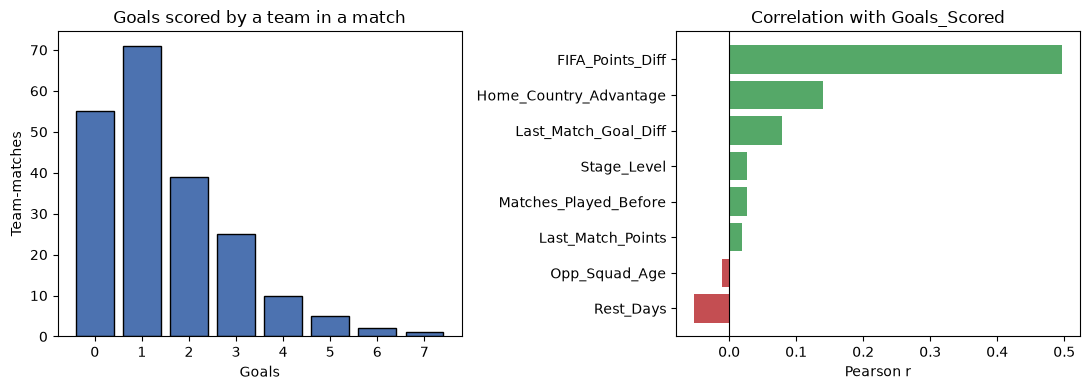

Mean goals per team-match: 1.48
Variance: 1.94
Scoreless team-matches: 55 of 208
Rest_Days                -0.05
Opp_Squad_Age            -0.01
Last_Match_Points         0.02
Matches_Played_Before     0.03
Stage_Level               0.03
Last_Match_Goal_Diff      0.08
Home_Country_Advantage    0.14
FIFA_Points_Diff          0.50


In [78]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: how many goals teams score in a match
counts = df[TARGET].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, edgecolor="black", color="#4C72B0")
axes[0].set_xticks(counts.index)
axes[0].set_title("Goals scored by a team in a match")
axes[0].set_xlabel("Goals")
axes[0].set_ylabel("Team-matches")

# Right: raw correlation of each feature with the target
corr = df[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
axes[1].barh(corr.index, corr.values, color=["#C44E52" if v < 0 else "#55A868" for v in corr.values])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlation with Goals_Scored")
axes[1].set_xlabel("Pearson r")

plt.tight_layout()
plt.savefig(FIGURES / "task22_eda.png", dpi=150)
plt.show()

print("Mean goals per team-match:", round(df[TARGET].mean(), 2))
print("Variance:", round(df[TARGET].var(), 2))
print("Scoreless team-matches:", int((df[TARGET] == 0).sum()), "of", len(df))
print(corr.round(2).to_string())

In [79]:
def fit_ols(data, features, target, groups=None):
    X = np.column_stack([np.ones(len(data)), data[features].to_numpy(float)])
    y = data[target].to_numpy(float)
    n, k = X.shape
    XtX_inv = np.linalg.inv(X.T @ X)
    beta = XtX_inv @ X.T @ y
    resid = y - X @ beta
    sigma2 = resid @ resid / (n - k)
    se = np.sqrt(np.diag(XtX_inv) * sigma2)
    t = beta / se
    p = 2 * stats.t.sf(np.abs(t), n - k)
    tcrit = stats.t.ppf(0.975, n - k)
    r2 = 1 - resid @ resid / ((y - y.mean()) ** 2).sum()
    adj = 1 - (1 - r2) * (n - 1) / (n - k)
    f = (r2 / (k - 1)) / ((1 - r2) / (n - k))
    table = pd.DataFrame({"coef": beta, "std_err": se, "t": t, "p_value": p,
                          "ci_low": beta - tcrit * se, "ci_high": beta + tcrit * se},
                         index=["Intercept"] + list(features))
    if groups is not None:                       # cluster-robust (CR1) p-values by match
        g = np.asarray(groups)
        meat = np.zeros((k, k))
        for gid in np.unique(g):
            idx = g == gid
            sg = X[idx].T @ resid[idx]
            meat += np.outer(sg, sg)
        G = len(np.unique(g))
        c = G / (G - 1) * (n - 1) / (n - k)
        se_c = np.sqrt(np.diag(c * XtX_inv @ meat @ XtX_inv))
        table["p_value_clustered"] = 2 * stats.t.sf(np.abs(beta / se_c), G - 1)
    stats_out = dict(r2=r2, adj_r2=adj, f=f, f_p=stats.f.sf(f, k - 1, n - k),
                     n=n, k=k - 1, resid=resid, fitted=X @ beta)
    return table, stats_out

table, s = fit_ols(df, FEATURES, TARGET, groups=df["Match_ID"])
table.round(3).to_csv(RESULTS / "task22_ols_table.csv")
print(table.round(3).to_string())
print(f"\nR2 = {s['r2']:.3f} | Adj R2 = {s['adj_r2']:.3f} | F = {s['f']:.2f} (p = {s['f_p']:.2g}) | n = {s['n']}")

                         coef  std_err      t  p_value  ci_low  ci_high  p_value_clustered
Intercept               3.516    2.007  1.752    0.081  -0.442    7.474              0.123
FIFA_Points_Diff        0.003    0.000  8.056    0.000   0.002    0.004              0.000
Stage_Level             0.150    0.209  0.717    0.474  -0.263    0.563              0.506
Rest_Days              -0.137    0.136 -1.009    0.314  -0.404    0.131              0.288
Home_Country_Advantage  0.639    0.363  1.759    0.080  -0.077    1.355              0.140
Matches_Played_Before  -0.077    0.176 -0.439    0.661  -0.423    0.269              0.667
Last_Match_Points      -0.271    0.139 -1.947    0.053  -0.546    0.003              0.111
Last_Match_Goal_Diff    0.094    0.084  1.109    0.269  -0.073    0.260              0.196
Opp_Squad_Age          -0.036    0.063 -0.571    0.569  -0.160    0.088              0.613

R2 = 0.276 | Adj R2 = 0.247 | F = 9.47 (p = 4.5e-11) | n = 208


In [80]:
EXPECTED = {"FIFA_Points_Diff": "+", "Stage_Level": "-", "Rest_Days": "+",
            "Home_Country_Advantage": "+", "Matches_Played_Before": "?",
            "Last_Match_Points": "+", "Last_Match_Goal_Diff": "+", "Opp_Squad_Age": "?"}

rows = []
for f_ in FEATURES:
    b, p, pc = table.loc[f_, "coef"], table.loc[f_, "p_value"], table.loc[f_, "p_value_clustered"]
    sign = "+" if b > 0 else "-"
    exp = EXPECTED[f_]
    direction = "no expectation" if exp == "?" else ("as expected" if exp == sign else "OPPOSITE")
    rows.append({"variable": f_, "expected": exp, "coef": round(b, 3),
                 "p_value": round(p, 3), "p_clustered": round(pc, 3),
                 "decision (5%)": "Reject H0" if p < 0.05 else "Fail to reject H0",
                 "same under clustering?": "yes" if (p < 0.05) == (pc < 0.05) else "NO",
                 "direction": direction})

hyp_results = pd.DataFrame(rows)
hyp_results.to_csv(RESULTS / "task22_hypotheses_vs_results.csv", index=False)
print(hyp_results.to_string(index=False))

              variable expected   coef  p_value  p_clustered     decision (5%) same under clustering?      direction
      FIFA_Points_Diff        +  0.003    0.000        0.000         Reject H0                    yes    as expected
           Stage_Level        -  0.150    0.474        0.506 Fail to reject H0                    yes       OPPOSITE
             Rest_Days        + -0.137    0.314        0.288 Fail to reject H0                    yes       OPPOSITE
Home_Country_Advantage        +  0.639    0.080        0.140 Fail to reject H0                    yes    as expected
 Matches_Played_Before        ? -0.077    0.661        0.667 Fail to reject H0                    yes no expectation
     Last_Match_Points        + -0.271    0.053        0.111 Fail to reject H0                    yes       OPPOSITE
  Last_Match_Goal_Diff        +  0.094    0.269        0.196 Fail to reject H0                    yes    as expected
         Opp_Squad_Age        ? -0.036    0.569        0.613 Fai

In [81]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate

def repeated_group_splits(groups, n_splits=5, n_repeats=10, seed=SEED):
    """Repeated K-fold where all rows of a group (match) stay in the same fold."""
    rng = np.random.default_rng(seed)
    groups = np.asarray(groups)
    uniq = np.unique(groups)
    splits = []
    for _ in range(n_repeats):
        fold_of = dict(zip(rng.permutation(uniq), np.arange(len(uniq)) % n_splits))
        folds = np.array([fold_of[g] for g in groups])
        for k in range(n_splits):
            splits.append((np.where(folds != k)[0], np.where(folds == k)[0]))
    return splits

X, y = df[FEATURES], df[TARGET]
splits = repeated_group_splits(df["Match_ID"])

# Leakage check: no match appears in both train and test
for tr, te in splits:
    assert set(df["Match_ID"].iloc[tr]).isdisjoint(set(df["Match_ID"].iloc[te]))

models = {
    "Baseline (mean)": DummyRegressor(strategy="mean"),
    "OLS": LinearRegression(),
    "Ridge": make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 30))),
    "Lasso": make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=SEED, max_iter=20000)),
    "Random forest": RandomForestRegressor(n_estimators=200, min_samples_leaf=5,
                                           random_state=SEED, n_jobs=-1),
}

rows = []
for name, model in models.items():
    r = cross_validate(model, X, y, cv=splits,
                       scoring=("neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"))
    rows.append({"model": name,
                 "RMSE": -r["test_neg_root_mean_squared_error"].mean(),
                 "RMSE_sd": r["test_neg_root_mean_squared_error"].std(),
                 "MAE": -r["test_neg_mean_absolute_error"].mean(),
                 "R2": r["test_r2"].mean()})

cv_results = pd.DataFrame(rows).round(3)
cv_results.to_csv(RESULTS / "task22_model_comparison.csv", index=False)
print(cv_results.to_string(index=False))
print("Number of train/test splits:", len(splits))

          model  RMSE  RMSE_sd   MAE     R2
Baseline (mean) 1.385    0.175 1.115 -0.029
            OLS 1.247    0.155 0.961  0.159
          Ridge 1.239    0.164 0.953  0.174
          Lasso 1.229    0.163 0.941  0.189
  Random forest 1.268    0.175 0.943  0.130
Number of train/test splits: 50


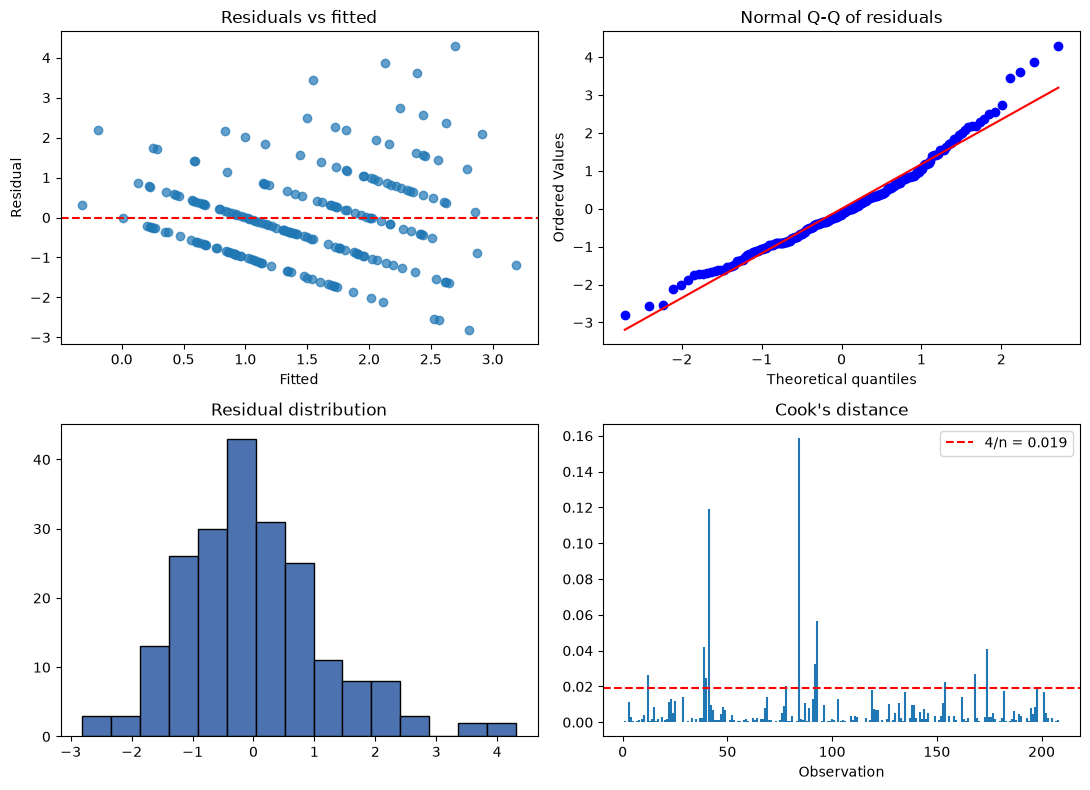

Shapiro-Wilk  W = 0.970, p = 0.000
Breusch-Pagan LM = 26.02, p = 0.001
Within-match residual correlation r = 0.16, p = 0.116

VIF:
FIFA_Points_Diff           1.06
Stage_Level                7.26
Rest_Days                  3.09
Home_Country_Advantage     1.10
Matches_Played_Before     12.00
Last_Match_Points          3.82
Last_Match_Goal_Diff       3.41
Opp_Squad_Age              1.03

Influential rows (Cook's D > 4/n): 11
 Match_ID       Team  Goals_Scored  cooks
      103    England             6  0.159
       27     Canada             6  0.119
        9    Germany             7  0.057
       87 Cabo Verde             2  0.042
       14      Spain             0  0.041
      103     France             4  0.033
      104  Argentina             0  0.027
       62    Senegal             5  0.027


In [82]:
resid, fitted = s["resid"], s["fitted"]
n_obs, k = s["n"], s["k"] + 1                     # k includes the intercept

# 1) Normality of residuals
sw_stat, sw_p = stats.shapiro(resid)

# 2) Constant variance: Breusch-Pagan (LM form)
Xc = np.column_stack([np.ones(n_obs), df[FEATURES].to_numpy(float)])
e2 = resid ** 2
g = np.linalg.lstsq(Xc, e2, rcond=None)[0]
r2_aux = 1 - ((e2 - Xc @ g) ** 2).sum() / ((e2 - e2.mean()) ** 2).sum()
bp_stat = n_obs * r2_aux
bp_p = stats.chi2.sf(bp_stat, k - 1)

# 3) Multicollinearity: VIF
Xf = df[FEATURES].to_numpy(float)
vifs = {}
for j, f in enumerate(FEATURES):
    others = np.column_stack([np.ones(n_obs), np.delete(Xf, j, axis=1)])
    b = np.linalg.lstsq(others, Xf[:, j], rcond=None)[0]
    r2j = 1 - ((Xf[:, j] - others @ b) ** 2).sum() / ((Xf[:, j] - Xf[:, j].mean()) ** 2).sum()
    vifs[f] = 1 / (1 - r2j)

# 4) Independence: do the two rows of the same match have correlated residuals?
pair = pd.DataFrame({"m": df["Match_ID"].values, "r": resid})
pair["i"] = pair.groupby("m").cumcount()
wide = pair.pivot(index="m", columns="i", values="r")
within_r, within_p = stats.pearsonr(wide[0], wide[1])

# 5) Influential observations: Cook's distance
h = np.diag(Xc @ np.linalg.inv(Xc.T @ Xc) @ Xc.T)
mse = (resid @ resid) / (n_obs - k)
cooks = resid ** 2 / (k * mse) * h / (1 - h) ** 2
thr = 4 / n_obs

fig, ax = plt.subplots(2, 2, figsize=(11, 8))
ax[0, 0].scatter(fitted, resid, alpha=0.7)
ax[0, 0].axhline(0, color="red", ls="--")
ax[0, 0].set_title("Residuals vs fitted"); ax[0, 0].set_xlabel("Fitted"); ax[0, 0].set_ylabel("Residual")
stats.probplot(resid, dist="norm", plot=ax[0, 1]); ax[0, 1].set_title("Normal Q-Q of residuals")
ax[1, 0].hist(resid, bins=15, edgecolor="black", color="#4C72B0"); ax[1, 0].set_title("Residual distribution")
ax[1, 1].stem(np.arange(1, n_obs + 1), cooks, markerfmt=" ", basefmt=" ")
ax[1, 1].axhline(thr, color="red", ls="--", label=f"4/n = {thr:.3f}")
ax[1, 1].set_title("Cook's distance"); ax[1, 1].set_xlabel("Observation"); ax[1, 1].legend()
plt.tight_layout()
plt.savefig(FIGURES / "task22_diagnostics.png", dpi=150)
plt.show()

print(f"Shapiro-Wilk  W = {sw_stat:.3f}, p = {sw_p:.3f}")
print(f"Breusch-Pagan LM = {bp_stat:.2f}, p = {bp_p:.3f}")
print(f"Within-match residual correlation r = {within_r:.2f}, p = {within_p:.3f}")
print("\nVIF:"); print(pd.Series(vifs).round(2).to_string())
inf = df.loc[cooks > thr, ["Match_ID", "Team", TARGET]].assign(cooks=cooks[cooks > thr].round(3))
print(f"\nInfluential rows (Cook's D > 4/n): {len(inf)}")
print(inf.sort_values("cooks", ascending=False).head(8).to_string(index=False))

In [83]:
from sklearn.linear_model import LinearRegression

d = df.copy()
d["Last_Match_Win"] = (d["Last_Match_Points"] == 3).astype(int)
d["Last_Match_GD_Capped"] = d["Last_Match_Goal_Diff"].clip(-3, 3)
d["Opp_Age_Distance"] = (d["Opp_Squad_Age"] - d["Opp_Squad_Age"].mean()).abs()

def swap(cols, old, new):
    return [new if c == old else c for c in cols]

VARIANTS = {
    "A. Original 8": FEATURES,
    "B. Last_Match_Points -> Last_Match_Win": swap(FEATURES, "Last_Match_Points", "Last_Match_Win"),
    "C. Last_Match_Goal_Diff -> capped at +/-3": swap(FEATURES, "Last_Match_Goal_Diff", "Last_Match_GD_Capped"),
    "D. Opp_Squad_Age -> distance from average age": swap(FEATURES, "Opp_Squad_Age", "Opp_Age_Distance"),
    "E. B + C together": swap(swap(FEATURES, "Last_Match_Points", "Last_Match_Win"),
                              "Last_Match_Goal_Diff", "Last_Match_GD_Capped"),
}

splits = repeated_group_splits(d["Match_ID"], n_repeats=20)
rows = []
for name, cols in VARIANTS.items():
    assert len(cols) == 8 and len(set(cols)) == 8, name       # never more than 8
    r = cross_validate(LinearRegression(), d[cols], d[TARGET], cv=splits,
                       scoring=("neg_root_mean_squared_error", "r2"))
    rows.append({"variant": name,
                 "RMSE": -r["test_neg_root_mean_squared_error"].mean(),
                 "R2": r["test_r2"].mean()})

opt = pd.DataFrame(rows)
opt["RMSE_change_vs_A"] = opt["RMSE"] - opt.loc[0, "RMSE"]
opt.round(3).to_csv(RESULTS / "task22_optimisation.csv", index=False)
print(opt.round(3).to_string(index=False))
print("\nBest variant:", opt.loc[opt["RMSE"].idxmin(), "variant"])

                                      variant  RMSE    R2  RMSE_change_vs_A
                                A. Original 8 1.255 0.144             0.000
       B. Last_Match_Points -> Last_Match_Win 1.245 0.157            -0.010
    C. Last_Match_Goal_Diff -> capped at +/-3 1.257 0.141             0.002
D. Opp_Squad_Age -> distance from average age 1.249 0.152            -0.006
                            E. B + C together 1.246 0.155            -0.009

Best variant: B. Last_Match_Points -> Last_Match_Win


In [84]:
SENS = [f for f in FEATURES if f != "Matches_Played_Before"]
t_full, s_full = fit_ols(df, FEATURES, TARGET, groups=df["Match_ID"])
t_sens, s_sens = fit_ols(df, SENS, TARGET, groups=df["Match_ID"])

cmp_ = pd.DataFrame({
    "coef_full": t_full["coef"], "p_full": t_full["p_value"],
    "coef_without": t_sens["coef"], "p_without": t_sens["p_value"],
}).loc[["Stage_Level"] + [f for f in SENS if f != "Stage_Level"]]

cmp_.round(3).to_csv(RESULTS / "task22_collinearity_sensitivity.csv")
print(cmp_.round(3).to_string())
print(f"\nAdj R2 full = {s_full['adj_r2']:.3f} | without Matches_Played_Before = {s_sens['adj_r2']:.3f}")

                        coef_full  p_full  coef_without  p_without
Stage_Level                 0.150   0.474         0.068      0.472
FIFA_Points_Diff            0.003   0.000         0.003      0.000
Rest_Days                  -0.137   0.314        -0.093      0.307
Home_Country_Advantage      0.639   0.080         0.612      0.088
Last_Match_Points          -0.271   0.053        -0.281      0.042
Last_Match_Goal_Diff        0.094   0.269         0.098      0.242
Opp_Squad_Age              -0.036   0.569        -0.035      0.575

Adj R2 full = 0.247 | without Matches_Played_Before = 0.250


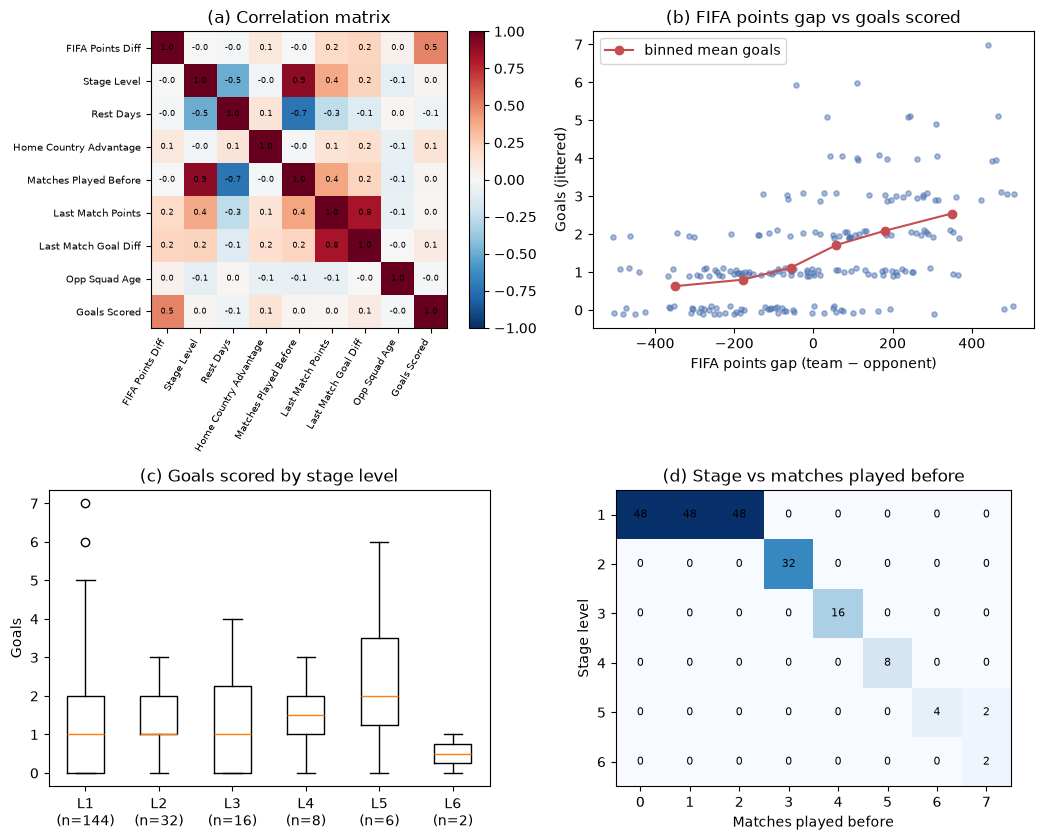

                         gap  goals
FIFA_Points_Diff                   
(-506.161, -247.645] -349.54   0.63
(-247.645, -109.17]  -178.48   0.80
(-109.17, 0.0]        -56.75   1.12
(0.0, 109.17]          58.24   1.71
(109.17, 247.645]     180.51   2.09
(247.645, 506.16]     349.54   2.54

Goals by host advantage:
                        mean  count
Home_Country_Advantage             
0                       1.43    195
1                       2.23     13


In [85]:
fig, ax = plt.subplots(2, 2, figsize=(11, 8.5))

# (a) correlation heatmap
cm = df[FEATURES + [TARGET]].corr()
im = ax[0, 0].imshow(cm.values, cmap="RdBu_r", vmin=-1, vmax=1)
labels = [c.replace("_", " ") for c in cm.columns]
ax[0, 0].set_xticks(range(len(cm))); ax[0, 0].set_yticks(range(len(cm)))
ax[0, 0].set_xticklabels(labels, rotation=60, ha="right", fontsize=7)
ax[0, 0].set_yticklabels(labels, fontsize=7)
for i in range(len(cm)):
    for j in range(len(cm)):
        ax[0, 0].text(j, i, f"{cm.values[i, j]:.1f}", ha="center", va="center", fontsize=6)
ax[0, 0].set_title("(a) Correlation matrix")
plt.colorbar(im, ax=ax[0, 0], fraction=0.046)

# (b) FIFA gap vs goals, with binned means
x, y = df["FIFA_Points_Diff"], df[TARGET]
jit = np.random.default_rng(SEED).uniform(-0.12, 0.12, len(df))
ax[0, 1].scatter(x, y + jit, alpha=0.5, color="#4C72B0", s=14)
g = df.groupby(pd.qcut(x, 6), observed=True).agg(gap=("FIFA_Points_Diff", "mean"), goals=(TARGET, "mean"))
ax[0, 1].plot(g["gap"], g["goals"], "o-", color="#C44E52", label="binned mean goals")
ax[0, 1].set_title("(b) FIFA points gap vs goals scored")
ax[0, 1].set_xlabel("FIFA points gap (team − opponent)"); ax[0, 1].set_ylabel("Goals (jittered)"); ax[0, 1].legend()

# (c) goals by stage level
stages = sorted(df["Stage_Level"].unique())
ax[1, 0].boxplot([df.loc[df["Stage_Level"] == k, TARGET] for k in stages])
ax[1, 0].set_xticks(range(1, len(stages) + 1))
ax[1, 0].set_xticklabels([f"L{k}\n(n={int((df['Stage_Level'] == k).sum())})" for k in stages])
ax[1, 0].set_title("(c) Goals scored by stage level"); ax[1, 0].set_ylabel("Goals")

# (d) why stage and matches-played are collinear
ct = pd.crosstab(df["Stage_Level"], df["Matches_Played_Before"])
ax[1, 1].imshow(ct.values, cmap="Blues")
ax[1, 1].set_xticks(range(ct.shape[1])); ax[1, 1].set_xticklabels(ct.columns)
ax[1, 1].set_yticks(range(ct.shape[0])); ax[1, 1].set_yticklabels(ct.index)
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax[1, 1].text(j, i, int(ct.values[i, j]), ha="center", va="center", fontsize=8)
ax[1, 1].set_title("(d) Stage vs matches played before")
ax[1, 1].set_xlabel("Matches played before"); ax[1, 1].set_ylabel("Stage level")

plt.tight_layout()
plt.savefig(FIGURES / "task22_eda_extended.png", dpi=150)
plt.show()

print(g.round(2).to_string())
print("\nGoals by host advantage:")
print(df.groupby("Home_Country_Advantage")[TARGET].agg(["mean", "count"]).round(2).to_string())

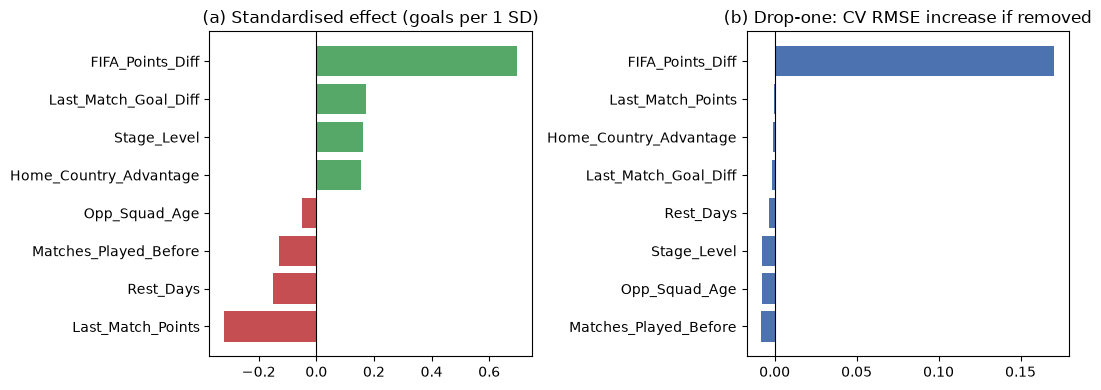

              variable  RMSE_without  RMSE_increase  folds_worse_%
      FIFA_Points_Diff         1.426          0.171           97.0
     Last_Match_Points         1.255         -0.001           61.0
Home_Country_Advantage         1.254         -0.001           50.0
  Last_Match_Goal_Diff         1.253         -0.002           58.0
             Rest_Days         1.252         -0.003           60.0
           Stage_Level         1.247         -0.008           42.0
         Opp_Squad_Age         1.247         -0.008           40.0
 Matches_Played_Before         1.247         -0.008           24.0

Standardised effects (goals per SD):
FIFA_Points_Diff          0.70
Last_Match_Goal_Diff      0.17
Stage_Level               0.16
Home_Country_Advantage    0.15
Opp_Squad_Age            -0.05
Matches_Played_Before    -0.13
Rest_Days                -0.15
Last_Match_Points        -0.32


In [86]:
splits = repeated_group_splits(df["Match_ID"], n_repeats=20)

def fold_rmse(model, cols, data=df):
    r = cross_validate(model, data[cols], data[TARGET], cv=splits,
                       scoring="neg_root_mean_squared_error")
    return -r["test_score"]

full = fold_rmse(LinearRegression(), FEATURES)
rows = []
for f in FEATURES:
    red = fold_rmse(LinearRegression(), [c for c in FEATURES if c != f])
    diff = red - full
    rows.append({"variable": f, "RMSE_without": red.mean(),
                 "RMSE_increase": diff.mean(), "folds_worse_%": 100 * (diff > 0).mean()})
drop = pd.DataFrame(rows).sort_values("RMSE_increase", ascending=False)
drop.round(3).to_csv(RESULTS / "task22_drop_one.csv", index=False)

Z = (df[FEATURES] - df[FEATURES].mean()) / df[FEATURES].std()
beta_z = np.linalg.lstsq(np.column_stack([np.ones(len(df)), Z.values]),
                         df[TARGET].values, rcond=None)[0][1:]
std_coef = pd.Series(beta_z, index=FEATURES).sort_values()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].barh(std_coef.index, std_coef.values, color=["#C44E52" if v < 0 else "#55A868" for v in std_coef.values])
ax[0].axvline(0, color="black", lw=0.8)
ax[0].set_title("(a) Standardised effect (goals per 1 SD)")
dp = drop.sort_values("RMSE_increase")
ax[1].barh(dp["variable"], dp["RMSE_increase"], color="#4C72B0")
ax[1].axvline(0, color="black", lw=0.8)
ax[1].set_title("(b) Drop-one: CV RMSE increase if removed")
plt.tight_layout()
plt.savefig(FIGURES / "task22_feature_performance.png", dpi=150)
plt.show()

print(drop.round(3).to_string(index=False))
print("\nStandardised effects (goals per SD):")
print(std_coef.sort_values(ascending=False).round(2).to_string())

In [ ]:
d = df.copy()
d["Last_Match_Win"] = (d["Last_Match_Points"] == 3).astype(int)
d["Opp_Age_Distance"] = (d["Opp_Squad_Age"] - d["Opp_Squad_Age"].mean()).abs()
BEST = [{"Last_Match_Points": "Last_Match_Win", "Opp_Squad_Age": "Opp_Age_Distance"}.get(c, c)
        for c in FEATURES]
assert len(BEST) == 8 and len(set(BEST)) == 8

ridge = lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 30)))
lasso = lambda: make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=SEED, max_iter=20000))

CANDIDATES = {
    "1. OLS, original 8": (LinearRegression(), FEATURES),
    "2. OLS, best 8 (win flag, age distance)": (LinearRegression(), BEST),
    "3. Ridge, original 8": (ridge(), FEATURES),
    "4. Lasso, original 8": (lasso(), FEATURES),
    "5. Ridge, best 8": (ridge(), BEST),
    "6. Lasso, best 8": (lasso(), BEST),
}

base = fold_rmse(*CANDIDATES["1. OLS, original 8"], data=d)
rows = []
for name, (m, cols) in CANDIDATES.items():
    f = fold_rmse(m, cols, data=d)
    diff = f - base
    rows.append({"candidate": name, "RMSE": f.mean(), "change_vs_1": diff.mean(),
                 "folds_improved_%": 100 * (diff < 0).mean()})

final22 = pd.DataFrame(rows)
final22.round(3).to_csv(RESULTS / "task22_final_candidates.csv", index=False)
print(final22.round(3).to_string(index=False))
print("\nBaseline (predict mean) RMSE:", round(float(np.sqrt(((d[TARGET] - d[TARGET].mean()) ** 2).mean())), 3))

Findings. `Last_Match_Points` has a sign opposite to our hypothesis and is borderline and fragile (p = 0.053, clustered p = 0.111, and p = 0.042 when `Matches_Played_Before` is dropped), so we do not treat it as a reliable effect.
Validation and alternatives. All cross-validation used folds grouped by Match_ID, so no match appears in both training and test sets. Ridge, Lasso and a random forest were compared with OLS: Lasso was nominally best (RMSE 1.229 vs 1.247 for OLS), but differences between models (about 0.04) are far smaller than fold-to-fold variation (SD ≈ 0.16), so the simple linear model is sufficient. Re-coding individual task-specific variables (best: win flag instead of last-match points, RMSE −0.010) gave no meaningful improvement, so we do not claim one; every variant replaced a variable, keeping exactly 8.

Assumption checks. Residuals are non-normal (Shapiro-Wilk p < 0.001) and heteroscedastic (Breusch-Pagan p = 0.001), which is expected for a discrete, right-skewed count of goals; p-values should therefore be read as approximate. Residuals of the two teams in the same match are only mildly correlated (r = 0.16, p = 0.12). No single observation dominates (largest Cook’s D ≈ 0.16).

**Multicollinearity.** `Matches_Played_Before` (VIF ≈ 12) and `Stage_Level` (VIF ≈ 7) are strongly collinear, because later matches mean more matches already played. A sensitivity refit without `Matches_Played_Before` (Cell 8b) shows the effect is limited: the `Stage_Level` coefficient halves (0.150 to 0.068) but remains non-significant (p ≈ 0.47 in both fits), `FIFA_Points_Diff` stays significant (p < 0.001), the other coefficients barely change, and Adj R² is essentially unchanged (0.247 vs 0.250). We therefore do not interpret the `Stage_Level` and `Matches_Played_Before` coefficients individually, but the main conclusion is robust to the collinearity.

Limitations.

208 team-matches from a single tournament; the two rows of each match share the same game conditions.
Early-tournament form variables rest on very few matches (shrunk towards a prior) and carry little information.
Goals scored is a count; a Poisson or negative-binomial model would be the natural alternative to linear regression, but the brief requires linear regression.
Football outcomes are highly random, so most of the variance remains unexplained by pre-match information.
Only 4 of the 8 variables are shared with Task 2.1, as required, which constrains how closely the two models can mirror each other.

Reminders:

Only the very first line starts with ##. The labels such as **Findings.** stay as bold text.
The cell type must be Markdown. Press Esc, then M, to convert it.
After you run it, it should render as formatted text with bold labels and bullets.